# Step 1: Data Collection & Understanding

Load the Olist E-Commerce dataset from the local 'dataset' subfolder.

Merge Orders, Order Items, and Reviews to create a unified user-item interaction dataframe.

In [16]:
import pandas as pd
import os

# Define the updated absolute path pointing to the new 'dataset' subfolder
data_path = r"C:\Users\Nathaniel Sayson\Documents\AIM\Capstone Project\dataset"

try:
    print(f"Attempting to load datasets from: {data_path}...")
    
    # Load the relevant datasets from the folder
    orders = pd.read_csv(os.path.join(data_path, 'olist_orders_dataset.csv'))
    items = pd.read_csv(os.path.join(data_path, 'olist_order_items_dataset.csv'))
    reviews = pd.read_csv(os.path.join(data_path, 'olist_order_reviews_dataset.csv'))
    print("Files successfully loaded!\n")
    
    # 1. Merge items and orders on 'order_id' to link products to customers
    df_merged = pd.merge(items, orders[['order_id', 'customer_id']], on='order_id', how='left')

    # 2. Merge the result with reviews to get the review_score (this will act as our rating)
    df_merged = pd.merge(df_merged, reviews[['order_id', 'review_score']], on='order_id', how='left')

    # Select and rename columns to match the standard format for Recommendation Systems
    df = df_merged[['customer_id', 'product_id', 'review_score', 'price']].copy()
    df.rename(columns={'customer_id': 'user_id', 'review_score': 'rating'}, inplace=True)

    # Drop any rows where the user didn't leave a rating (we need ratings to train the model)
    df.dropna(subset=['rating'], inplace=True)

    # Display dataset overview
    print("Olist Dataset Info:")
    df.info()

    print("\nFirst 5 rows:")
    print(df.head())

except FileNotFoundError as e:
    print(f"\n❌ Error: {e}")
    print("Please make sure you have created the 'dataset' folder and unzipped the CSV files directly inside it.")

Attempting to load datasets from: C:\Users\Nathaniel Sayson\Documents\AIM\Capstone Project\dataset...
Files successfully loaded!

Olist Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 112372 entries, 0 to 113313
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     112372 non-null  object 
 1   product_id  112372 non-null  object 
 2   rating      112372 non-null  float64
 3   price       112372 non-null  float64
dtypes: float64(2), object(2)
memory usage: 4.3+ MB

First 5 rows:
                            user_id                        product_id  rating  \
0  3ce436f183e68e07877b285a838db11a  4244733e06e7ecb4970a6e2683c13e61     5.0   
1  f6dd3ec061db4e3987629fe6b26e5cce  e5f2d52b802189ee658865ca93d83a8f     4.0   
2  6489ae5e4333f3693df5ad4372dab6d3  c777355d18b72b67abbeef9df44fd0fd     5.0   
3  d4eb9395c8c0431ee92fce09860c5a06  7634da152a4610f1595efa32f14722fc     4.0   
4  58dbd0b2d70206bf40

# Step 2: Data Preprocessing, Applied EDA & Feature Engineering
Handle any remaining missing values and duplicates.

Perform EDA to visualize the distribution of ratings and prices.

Engineer features: Create a 'user_activity' metric and a 'socioeconomic_proxy' (price tier) to use for our bias auditing later.

<class 'pandas.core.frame.DataFrame'>
Index: 101855 entries, 0 to 113313
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     101855 non-null  object 
 1   product_id  101855 non-null  object 
 2   rating      101855 non-null  float64
 3   price       101855 non-null  float64
dtypes: float64(2), object(2)
memory usage: 3.9+ MB


C:\Users\Nathaniel Sayson\AppData\Local\Temp\ipykernel_3644\395346500.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', palette='viridis')


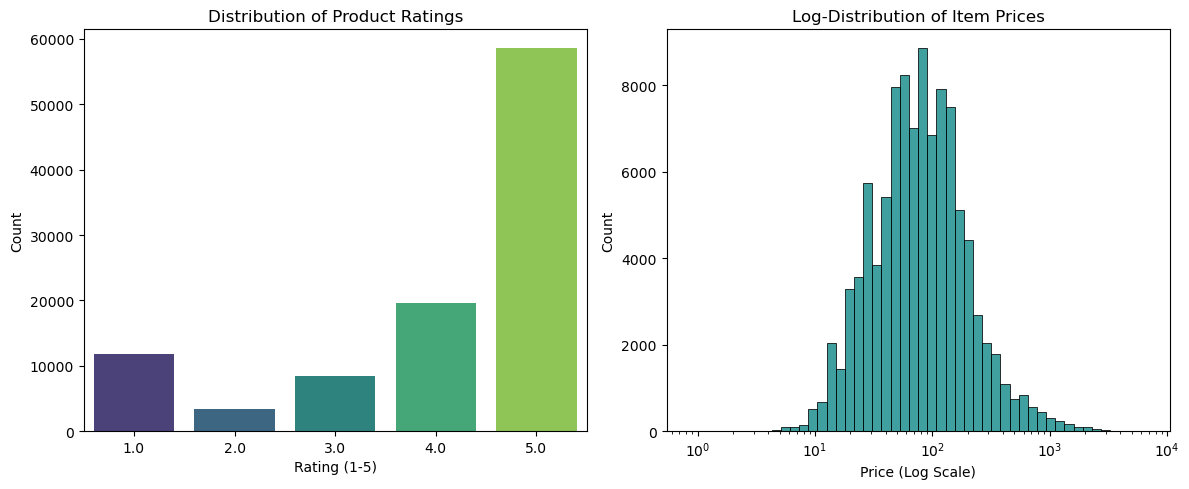

Cleaned and Engineered Data (First 3 rows):
                            user_id                        product_id  rating  \
0  3ce436f183e68e07877b285a838db11a  4244733e06e7ecb4970a6e2683c13e61     5.0   
1  f6dd3ec061db4e3987629fe6b26e5cce  e5f2d52b802189ee658865ca93d83a8f     4.0   
2  6489ae5e4333f3693df5ad4372dab6d3  c777355d18b72b67abbeef9df44fd0fd     5.0   

   price  interaction_count  avg_purchase_price price_tier  
0   58.9                  1                58.9  Mid-Range  
1  239.9                  1               239.9    Premium  
2  199.0                  1               199.0    Premium  


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Clean Data: Drop exact duplicate interactions to avoid model bias
df.drop_duplicates(inplace=True)

# Clean Data: Fill any missing prices with the median price
df['price'] = df['price'].fillna(df['price'].median())

# Applied EDA: Visualize the distribution of ratings
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='rating', palette='viridis')
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating (1-5)')
plt.ylabel('Count')

# Applied EDA: Visualize the distribution of prices (log scale due to right-skewness)
plt.subplot(1, 2, 2)
sns.histplot(df['price'], bins=50, log_scale=True, color='teal')
plt.title('Log-Distribution of Item Prices')
plt.xlabel('Price (Log Scale)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Feature Engineering: Calculate total interactions per user (User Activity)
user_activity = df.groupby('user_id').size().reset_index(name='interaction_count')
df = df.merge(user_activity, on='user_id')

# Feature Engineering: Create a 'Socioeconomic Proxy' based on average purchase price per user
# We will bin users into 'Budget', 'Mid-Range', and 'Premium' shoppers
user_avg_price = df.groupby('user_id')['price'].mean().reset_index(name='avg_purchase_price')
df = df.merge(user_avg_price, on='user_id')

# Binning into tiers using quantiles (33rd and 66th percentiles)
p33 = df['avg_purchase_price'].quantile(0.33)
p66 = df['avg_purchase_price'].quantile(0.66)

def assign_price_tier(price):
    if price <= p33:
        return 'Budget'
    elif price <= p66:
        return 'Mid-Range'
    else:
        return 'Premium'

df['price_tier'] = df['avg_purchase_price'].apply(assign_price_tier)

print("Cleaned and Engineered Data (First 3 rows):")
print(df.head(3))

# Step 3: Model Implementation
Implement a Collaborative Filtering recommendation model using Singular Value Decomposition (SVD).

We will use the Surprise library to split the dataset, train the model, and evaluate it using RMSE.

In [12]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

# Define the reader format for the surprise library (ratings in Olist are 1 to 5)
reader = Reader(rating_scale=(1, 5))

# Load the Olist dataframe columns into a surprise Dataset object
# Surprise requires strictly: user_id, item_id, rating
data_surprise = Dataset.load_from_df(df[['user_id', 'product_id', 'rating']], reader)

# Split the dataset into training (80%) and testing (20%) sets
trainset, testset = train_test_split(data_surprise, test_size=0.2, random_state=42)

# Initialize the Singular Value Decomposition (SVD) algorithm
# We use 50 latent factors to capture underlying patterns between users and items
model = SVD(n_factors=50, random_state=42)

# Train the collaborative filtering model on the training set
print("Training the SVD Collaborative Filtering model...")
model.fit(trainset)

# Predict product ratings for the unseen test set
predictions = model.test(testset)

# Evaluate the model's predictive accuracy using Root Mean Square Error (RMSE)
rmse = accuracy.rmse(predictions)
print(f"\nOverall Model RMSE: {rmse:.4f}")

Training the SVD Collaborative Filtering model...
RMSE: 1.3386

Overall Model RMSE: 1.3386


# Step 4: Critical Thinking, Ethical AI & Bias Auditing
Since the Olist dataset lacks explicit demographic data (gender, race, age), we will use our engineered 'price_tier' as a socioeconomic proxy.

We will audit the model to see if it provides less accurate recommendations (higher RMSE) for 'Budget' shoppers compared to 'Premium' shoppers.

In [13]:
from collections import defaultdict

# Create a dictionary mapping each user_id to their engineered socioeconomic proxy (price tier)
user_tier_map = dict(zip(df['user_id'], df['price_tier']))

# Group the model's test predictions by the user's socioeconomic tier
predictions_by_tier = defaultdict(list)
for pred in predictions:
    # pred.uid accesses the raw user_id in the test set
    tier = user_tier_map[pred.uid]
    predictions_by_tier[tier].append(pred)

# Calculate and print the RMSE for each individual socioeconomic group to audit fairness
print("Bias Audit: RMSE by Socioeconomic Proxy (Price Tier)")
print("-" * 55)
for tier, group_preds in predictions_by_tier.items():
    # Calculate RMSE specifically for the current subgroup
    group_rmse = accuracy.rmse(group_preds, verbose=False)
    print(f"Shopper Segment: {tier: <10} | RMSE: {group_rmse:.4f} | Sample Size: {len(group_preds)}")

# Output a proposed mitigation strategy based on the audit
print("\n--- Fairness Analysis & Mitigation ---")
print("If the 'Budget' segment has a higher error rate, it implies algorithmic bias against lower-income proxies.")
print("Mitigation Strategies:")
print("1. Stratified Sampling: Ensure equal representation of Budget and Premium interactions during model training.")
print("2. Separate Models: Train a dedicated collaborative filter specifically for budget-tier interactions.")
print("3. Feature Injection: Switch to a Content-Based or Hybrid model that explicitly factors in 'price' as an input variable.")

Bias Audit: RMSE by Socioeconomic Proxy (Price Tier)
-------------------------------------------------------
Shopper Segment: Budget     | RMSE: 1.3179 | Sample Size: 6735
Shopper Segment: Mid-Range  | RMSE: 1.3386 | Sample Size: 6661
Shopper Segment: Premium    | RMSE: 1.3583 | Sample Size: 6975

--- Fairness Analysis & Mitigation ---
If the 'Budget' segment has a higher error rate, it implies algorithmic bias against lower-income proxies.
Mitigation Strategies:
1. Stratified Sampling: Ensure equal representation of Budget and Premium interactions during model training.
2. Separate Models: Train a dedicated collaborative filter specifically for budget-tier interactions.
3. Feature Injection: Switch to a Content-Based or Hybrid model that explicitly factors in 'price' as an input variable.
